## Fixed Income Relative Value Analytics
* Python replication of Barclays methodology adjusting Euro government inflation linkers for technical factors
* **Source**: Barclays Global Inflation-Linked Products: User's Guide (page 37 and 288)

### Euro Inflation-Indexed Government Bonds
* Euro linkers follow the non-seasonally-adjusted Euro area HICPxT index (published by Eurostat)
* Breakeven inflation rates for linkers tracking the same index but maturing in different months are distorted
* Euro linkers offer a par deflation floor (put option) at maturity (principal repayment cannot be lower than the original par amount)
* Dirty price is adjusted for the seasonality distortion and the deflation floor value
* The option- and seasonality-adjusted dirty price is the basis for relative valuation of the Euro government linker bond class
* Bond prices, zero-coupon riskless curves (SOFR, ESTR) and volatilities from the caps and floors market obtained from Bloomberg Terminal

### Zero-Coupon Inflation Swaps
* Pricing of the zero-coupon Euro area HICPxT inflation swap curve (5- to 7-year segment)
* Application of a seasonality overlay to derive rates of swaps with non-integer maturities
* Conventions, seasonality adjustment and market data obtained from Barclays
* **Source**: Barclays Global Inflation-Linked Products: User's Guide (pages 31 and 103)
* **Sample US ZC CPI Inflation Swap Specs**: https://tpicap.com/coexpartners/sites/g/files/escbpb146/files/2021-04/IRP%20MET%20TEMPLATE%20US%20CPI%20ZC%20INFLATION%20SWAP.pdf

In [35]:
# ZERO-COUPON INFLATION SWAP CURVE 

import QuantLib as ql
import pandas as pd

# assumed trade date: July 13, 2026
# ZeroCouponInflationSwapHelper assumes evaluation date == settlement date => inconsistent with T+2 (US ZC CPI swaps)
# overwrite with the actual settlement date
# Euro HICPxT swap => 15-to-15 settlement convention
# Euro linker => T+2 settlement
# evaluation date shifted to accommodate settlement dates of both ZC inflation swaps and inflation-indexed STRIPS bonds

today = ql.Date(15, ql.July, 2026)
ql.Settings.instance().evaluationDate = today

# Euro area HICP excluding tobacco, non-seasonally adjusted
# documentation: https://quantlib-python-docs.readthedocs.io/en/latest/indexes.html
# Euro area HICPxT NSA source: https://ec.europa.eu/eurostat/databrowser/view/ei_cphi_m__custom_22069970/default/table
index = ql.EUHICPXT()


# past index values (seasonally unadjusted)
inflation_fixings = [
    ((2026, ql.March), 101.96000),
    ((2026, ql.April), 103.02),
    ((2026, ql.May), 103.10000)

]

# past fixings assigned to the first day of the relevant month
for (year, month), fixing in inflation_fixings:
    index.addFixing(ql.Date(1, month, year), fixing)

# market ZC inflation swap rate quotes
inflation_quotes = [
    (ql.Period(5, ql.Years), 1.03),
    (ql.Period(6, ql.Years), 1.07),
    (ql.Period(7, ql.Years), 1.09),
]

# source: https://quantlib-python-docs.readthedocs.io/en/latest/dates.html
# Euro area HICPxT swaps => TARGET
# US ZC CPI swaps => ql.UnitedStates(ql.UnitedStates.GovernmentBond)
calendar = ql.TARGET()

# 3-month lag
observation_lag = ql.Period(3, ql.Months)
# inflation swaps daycount convention (consistent with 1/1)
# 1/1 daycount definition: https://quant.stackexchange.com/questions/40283/day-count-fraction-specified-as-1-1-2006-isda-section-4-16-a
# source: https://github.com/lballabio/QuantLib/issues/2454
# definition: https://rkapl123.github.io/QLAnnotatedSource/d5/d98/class_quant_lib_1_1_simple_day_counter.html
day_counter = ql.SimpleDayCounter()
# interpolation methods: https://rkapl123.github.io/QLAnnotatedSource/d4/db8/inflationindex_8hpp_source.html#l00042
# Linear => US CPI
# Flat => Euro area HICPxT - euro government linkers trade on interpolated basis, the method is therefore overwritten for a more accurate index forecast
interpolation = ql.CPI.Linear

# redundant in the new version of QuantLib
nominal_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.03, ql.Actual365Fixed())
)

# source: https://quantlib-python-docs.readthedocs.io/en/latest/thelpers.html#ql.ZeroCouponInflationSwapHelper
# source code: https://github.com/lballabio/QuantLib/blob/master/ql/termstructures/inflation/inflationhelpers.cpp
helpers = []

for tenor, quote in inflation_quotes:
    maturity = (today + tenor)
    # calculation period end date is not adjusted => the maturity date does not follow the Modified Following convention
    # source: https://github.com/lballabio/QuantLib/issues/2454
    print(maturity)
    helpers.append(
        ql.ZeroCouponInflationSwapHelper(
            ql.makeQuoteHandle(quote / 100),
            observation_lag,
            maturity,
            calendar,
            ql.ModifiedFollowing,
            # payment date is adjusted according to the Modified Following standard
            day_counter,
            index,
            interpolation,
            # nominal_curve, # redundant argument
            # ql.Pillar.MaturityDate,
            # pillar definition: https://rkapl123.github.io/QLAnnotatedSource/de/d54/struct_quant_lib_1_1_pillar.html#ac5102e0b11ce43d0b9ef595c3c3ab0c3
            # QuantLib pillar code update: https://github.com/lballabio/QuantLib/issues/2454
            # pillar code: https://rkapl123.github.io/QLAnnotatedSource/d0/d76/bootstraphelper_8hpp_source.html#l00042
        )
    )

# inflation index publication frequency
fixing_frequency = ql.Monthly

# trade date => observed quotes
# observation date (see https://quant.stackexchange.com/questions/39671/why-we-should-specify-the-evaluation-date-when-using-quantlib-yield-curve-and-w/40158?utm_source=chatgpt.com)
# definition: https://www.quantlibguide.com/Term%20structures.html
curve_date = ql.Date(13, ql.July, 2026)

# passed index fixing value => most recently published 
# source: https://quantlib-python-docs.readthedocs.io/en/latest/termstructures/inflation.html#ql.PiecewiseZeroInflation
# interpolation method used by QuantLib: linear interpolation of zero inflation rates (not INDEX interpolation)
# source: https://github.com/lballabio/QuantLib/blob/master/ql/termstructures/inflation/interpolatedzeroinflationcurve.hpp
# Barclays material => log linear index interpolation (page 105)
inflation_curve = ql.PiecewiseZeroInflation(
    curve_date, index.lastFixingDate(), fixing_frequency, day_counter, helpers
)

# inflation_curve properties linked to a handle
inflation_handle = ql.RelinkableZeroInflationTermStructureHandle(
    inflation_curve
)

# properties of the inflation swap curve handle linked to the inflation index (Euro HICPxT)
hicp = ql.EUHICPXT(inflation_handle)

# current inflation index (settlement date)
current_index = ql.CPI.laggedFixing(
    hicp, ql.Date(17, ql.July, 2026), ql.Period(3, ql.Months), ql.CPI.Linear
)
print(current_index)

# forecast inflation index (maturity date)
forecast_index = (ql.CPI.laggedFixing(
    hicp, ql.Date(17, ql.July, 2032), ql.Period(3, ql.Months), ql.CPI.Linear
))
print(forecast_index)

July 17th, 2031
July 17th, 2032
July 17th, 2033
103.06129032258065
109.8573629092045


In [ ]:
# INFLATION-INDEXED STRIPS BOND PRICING - REAL CASH FLOWS

# calendars: https://quantlib-python-docs.readthedocs.io/en/latest/dates.html
# daycount conventions: https://rkapl123.github.io/QLAnnotatedSource/db/d36/group__daycounters.html
# ACT/ACT: https://rkapl123.github.io/QLAnnotatedSource/de/dee/class_quant_lib_1_1_actual_actual.html
# ICMA definition: https://assets.isda.org/media/fa424a78/cc62a780-pdf/

# source: https://rkapl123.github.io/QLAnnotatedSource/d5/d5b/class_quant_lib_1_1_schedule.html
schedule = ql.Schedule(
    ql.Date(17, ql.July, 2025),
    # first coupon = effective date
    ql.Date(17, ql.July, 2032),
    # last coupon = terminal date
    ql.Period(ql.Annual),
     # coupon frequency per annum
    ql.TARGET(),
    # calendar
    # ql.ModifiedFollowing,
    # ql.ModifiedFollowing,
    ql.Unadjusted,
    # business date convention (calculation period)
    ql.Unadjusted,
    # business date convention of the terminal date
    ql.DateGeneration.Backward,
    # from the effective to the terminal date
    # identical to ql.DateGeneration.Forward for plain vanilla bonds with a regular coupon distribution schedule
    False,
    # end-of-month 
) 

settlement_days = 0 # T+2 in reality, shifted to accommodate ZCIS
face_amount = 100.0 # original face value of the bond
coupons = [0.00] # STIPS = zero-coupon bond
payment_day_counter = ql.ActualActual(ql.ActualActual.ISMA, schedule) # ACT/ACT is the prevailing euro linker bond market daycount convention

# bond parameters
# documentation: https://quantlib-python-docs.readthedocs.io/en/latest/instruments/fixedincome.html
strips = ql.FixedRateBond(
    settlement_days, face_amount, schedule, coupons, payment_day_counter, ql.Unadjusted # ql.ModifiedFollowing
)

# bond pricing
# real yield-to-maturity = 3.5%
# euro linkers (barring Italian BTPs) distribute coupons annually (that transfers to STRIPS as well)
# source: https://www.aft.gouv.fr/en/stripped-government-securities

strips_price = strips.dirtyPrice(
    0.035,
    ql.ActualActual(ql.ActualActual.ISMA, schedule),
    ql.Compounded,
    ql.Annual,
)
print(strips_price)
# price level equal to the dated date (base inflation index of the bond)
# augmentation to current price level via multiplication by the current inflation index ratio

base_cpi = 100 # index value on the dated date
strips_price_uplift = strips_price*(current_index/base_cpi)
# current index = inflation index value on the settlement date

print(strips_price_uplift)


81.35006443077528
83.84042608060771


In [ ]:
# INFLATION-INDEXED STRIPS BOND PRICING - NOMINAL CASH FLOWS (NO SEASONALITY)

schedule = ql.Schedule(
    ql.Date(17, ql.July, 2025),
    ql.Date(17, ql.July, 2032),
    ql.Period(ql.Annual),
    ql.TARGET(),
    # ql.ModifiedFollowing,
    # ql.ModifiedFollowing,
    ql.Unadjusted,
    ql.Unadjusted,
    ql.DateGeneration.Backward,
    False,
)

settlement_days = 0 # T+2 settlement applies in reality, adjusted to accommodate the inflation swap curve
face_amount = 100.0 # original face value of the linker
growth_only = False # redundant object
base_cpi = 100 # base/dated date CPI index
observation_lag = ql.Period(3, ql.Months) # 3-month observation lag (both linkers and ZCIS)
fixed_rate = 0.00 # real coupon rate

# bond parameters + ZC inflation curve
# the forecast index ratio is applied to the linker's cash flows = from real to nominal
# methodology: Barclays Global Inflation-Linked Products: User's Guide (page 37)

bond = ql.CPIBond(
    settlement_days,
    face_amount,
    growth_only,
    base_cpi,
    observation_lag,
    hicp, # passed ZC inflation swap curve
    ql.CPI.Linear,
    schedule, # passed cash flow schedule
    [fixed_rate],
    ql.ActualActual(ql.ActualActual.ISMA, schedule),
    ql.Unadjusted,
    # ql.ModifiedFollowing,
)
# ql.Unadjusted = street yield (conventional for ACT/ACT ICMA bonds)
# ql.ModifiedFollowing = true yield
# forecast inflation index value insensitive to the selected convention (SimpleDayCounter applies)
# ActualActual standard pertains to calculating the coupon accrual

In [ ]:
# REPAYMENT SCHEDULE
# coupons accrual does not account for bad dates (in reality, the actual cash coupon payment follows the Modified Following convention)

import numpy as np

coupon_data = []

for cf in bond.cashflows():
    c = ql.as_cpi_coupon(cf)
    # cash flows expressed in nominal, not real, units
    if c is not None:
        coupon_data.append(
            (c.date(), c.rate(), c.indexFixing(), c.amount())
        )
    else:
        coupon_data.append((cf.date(), np.nan, np.nan, cf.amount()))

df = pd.DataFrame(
    coupon_data, columns=("date", "rate", "index fixing", "amount")
)
df.style.format(
    {"rate": "{:.4%}", "index fixing": "{:.2f}", "amount": "{:.4f}"}
)

,date,rate,index fixing,amount
0,"July 17th, 2026",nan%,nan,0.0000
1,"July 17th, 2027",nan%,nan,0.0000
2,"July 17th, 2028",nan%,nan,0.0000
3,"July 17th, 2029",nan%,nan,0.0000
4,"July 17th, 2030",nan%,nan,0.0000
5,"July 17th, 2031",nan%,nan,0.0000
6,"July 17th, 2032",nan%,nan,0.0000
7,"July 17th, 2032",nan%,nan,109.8574


In [ ]:
# BOND PRICING
# dirty price (consistent with the street yield convention) - NO SEASONALITY ADJUSTMENT

bond_price = bond.dirtyPrice(
    0.035, # real YTM of the linker
    ql.ActualActual(ql.ActualActual.ISMA, schedule),
    ql.Compounded,
    ql.Annual,
)
print(bond_price)
# ActualActual applicable to the discount factor

89.36903550858848


#### Result Verification

In [40]:
# 6-year-ahead forecast inflation index value
x = current_index*((1+1.07/100)**(6))
print(x)

# dirty price of a STRIPS bond maturing in 6 years
y = x/((1+0.035)**(6))
print(y)

109.85736290920454
89.36903550858852


In [ ]:
# SEASONALLY-ADJUSTED ZCIS CURVE

# multiplicative cumulative seasonal factor Π

# US NSA CPI index source (including the seasonality vector): https://www.bls.gov/cpi/seasonal-adjustment/
# Euro area HICPxT NSA source: https://ec.europa.eu/eurostat/databrowser/view/ei_cphi_m__custom_22069970/default/table
# trailing twelve months data: https://ec.europa.eu/eurostat/databrowser/view/teicp240/default/table?lang=en
# Euro area HICPxT SA source: https://data.ecb.europa.eu/data/datasets/HICP/HICP.M.U2.Y.X02300.4F0.INX
# seasonality factor = NSA index/SA index

seasonalityFactors = [
    0.988361709,
    0.990403086,
    0.998667822,
    0.999926584,
    1.001658259,
    1.001168980,
    0.995576907,
    0.996059673,
    0.999327218,
    1.000283364,
    0.998557554,
    1.000000000,
]

# first value of the vector set to January
seasonality = ql.MultiplicativePriceSeasonality(
    ql.Date(1, ql.January, 2026), ql.Monthly, seasonalityFactors
)

# seasonality applied to the Euro HICPxT inflation swap curve
inflation_curve.setSeasonality(seasonality)

# seasonally-adjusted inflation_curve properties linked to a handle
inflation_handle_season = ql.RelinkableZeroInflationTermStructureHandle(
    inflation_curve
)

# seasonally-adjusted inflation index
hicp_season = ql.EUHICPXT(inflation_handle_season)

# forecast inflation idnex value on the maturity date
# in case the time to maturity from the settlement date is an integer, seasonality does not impact the resulting value
forecast_index_season = (ql.CPI.laggedFixing(
    hicp_season, ql.Date(17, ql.July, 2032), ql.Period(3, ql.Months), ql.CPI.Linear
))
print(forecast_index_season)

109.85736290920391


In [ ]:
# SEASONALLY-ADJUSTED BOND AND CASH FLOW SCHEDULE

# bond parameters + seasonally-adjusted ZC inflation curve 
bond_season = ql.CPIBond(
    settlement_days,
    face_amount,
    growth_only,
    base_cpi,
    observation_lag,
    hicp_season, # passed ZC inflation swap curve (SA)
    ql.CPI.Linear,
    schedule, # passed cash flow schedule
    [fixed_rate],
    ql.ActualActual(ql.ActualActual.ISMA, schedule),
    ql.Unadjusted,
    # ql.ModifiedFollowing,
)

# cash flow schedule = same principles as above
coupon_data = []

for cf in bond_season.cashflows():
    c = ql.as_cpi_coupon(cf)
    if c is not None:
        coupon_data.append(
            (c.date(), c.rate(), c.indexFixing(), c.amount())
        )
    else:
        coupon_data.append((cf.date(), np.nan, np.nan, cf.amount()))

df = pd.DataFrame(
    coupon_data, columns=("date", "rate", "index fixing", "amount")
)
df.style.format(
    {"rate": "{:.4%}", "index fixing": "{:.2f}", "amount": "{:.4f}"}
)

,date,rate,index fixing,amount
0,"July 17th, 2026",nan%,nan,0.0000
1,"July 17th, 2027",nan%,nan,0.0000
2,"July 17th, 2028",nan%,nan,0.0000
3,"July 17th, 2029",nan%,nan,0.0000
4,"July 17th, 2030",nan%,nan,0.0000
5,"July 17th, 2031",nan%,nan,0.0000
6,"July 17th, 2032",nan%,nan,0.0000
7,"July 17th, 2032",nan%,nan,109.8574


In [ ]:
# BOND PRICING
# dirty price (consistent with the street yield convention) + SA

bond_season_price = bond_season.dirtyPrice(
    0.035, # real YTM of the linker
    ql.ActualActual(ql.ActualActual.ISMA, schedule),
    ql.Compounded,
    ql.Annual,
)
# ActualActual applicable to the discount factor

print(bond_season_price)

89.36903550858803


In [ ]:
# LOG-NORMAL BLACK SCHOLES PRICING MODEL => DEFLATION FLOOR PUT OPTION
# documentation: https://quantlib-python-docs.readthedocs.io/en/latest/pricing_engines.html
# see the attached Excel file deflation_floor.xlsx for more information
# methodology: Barclays Global Inflation-Linked Products: User's Guide (page 130)

# time to maturity in years
start = ql.Date(17, ql.July, 2026) # settlement date
end   = ql.Date(17, ql.July, 2032) # bond/inflation swap maturity

# ZC inflation swap market convention = simple daycount
t = day_counter.yearFraction(start, end)
print(t)

# shifted-log-normal volatility σ implied by the zero-coupon inflation-indexed floor market
volatility = 0.045

# ZC SOFR/ESTR curve daycount convention = ACT/365, continuous compounding
dc = ql.Actual365Fixed()
t_sofr = dc.yearFraction(start, end)

# ZC SOFR/ESTR rate corresponding to the maturity
ir = 0.04

type = ql.Option.Put # deflation floor is a put option
strike = face_amount # strike price is the minimal possible repayment, or the bond original face value times inflation index ratio of 1
forward = (forecast_index_season/base_cpi)*face_amount # original bond face value times the current/settlement date index ratio carried forward by the corresponding ZC inflation rate
stdDev = volatility*((t**(1/2))) # stdDev = σ√T
discount = np.exp(-ir*t_sofr) # discount factor (derived from the riskless SOFR/ESTR curve)

# dollar/euro present value of the deflation floor put option embedded in the linker
deflation_floor = ql.blackFormula(type, strike, forward, stdDev, discount)
print(deflation_floor)


6.0
0.9931059284473153


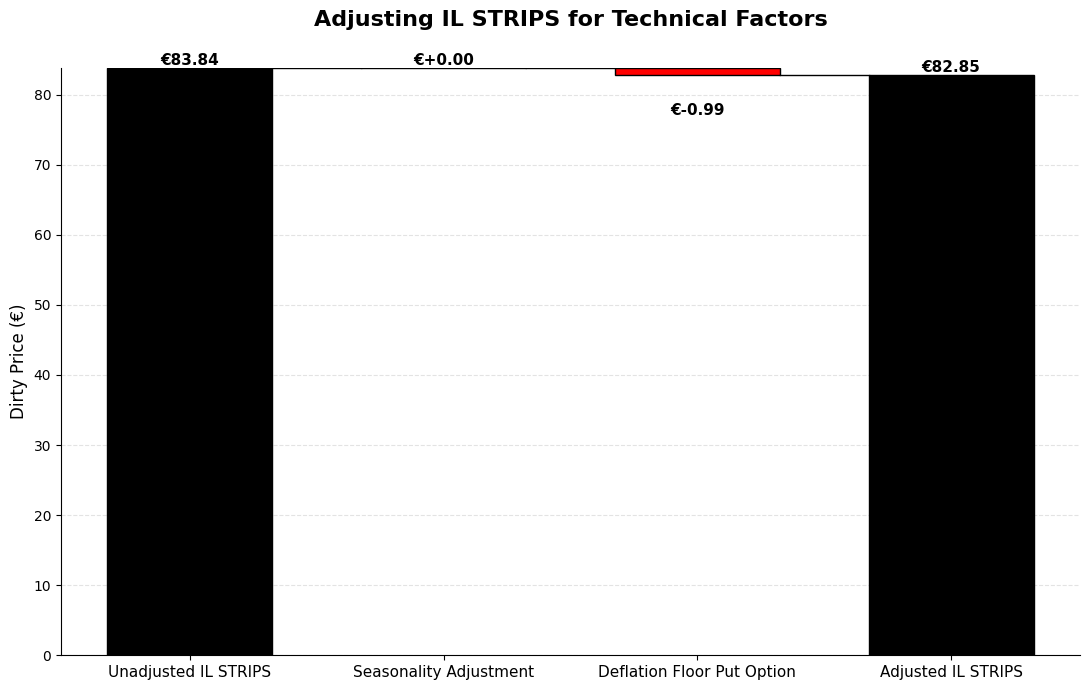

In [ ]:
# VISUALIZATION

# adjustment of the dirty price of the linker for technical factors (deflation floor, seasonality)
# necessary for Fixed Income Relative Value = comparison of richness/cheapness of bonds belonging to the same class
# source: Barclays Global Inflation-Linked Products: User's Guide (page 288)

# seasonally- and option-adjusted price
adjusted_price = strips_price_uplift + (bond_price - bond_price) - deflation_floor

# bar chart
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Values
# ------------------------------------------------------------------

# Starting value
unadjusted_price = strips_price_uplift

# Seasonality adjustment
seasonality_adjustment = bond_price - bond_season_price

# Deflation floor put option
deflation_floor_adjustment = -float(deflation_floor)

# Final adjusted price
adjusted_price = (
    unadjusted_price
    + seasonality_adjustment
    + deflation_floor_adjustment
)

# Optional consistency check
assert np.isclose(adjusted_price, float(adjusted_price))


# ------------------------------------------------------------------
# Waterfall data
# ------------------------------------------------------------------

labels = [
    "Unadjusted IL STRIPS",
    "Seasonality Adjustment",
    "Deflation Floor Put Option",
    "Adjusted IL STRIPS"
]

values = [
    unadjusted_price,
    seasonality_adjustment,
    deflation_floor_adjustment,
    adjusted_price
]


# ------------------------------------------------------------------
# Calculate bar bottoms and heights
# ------------------------------------------------------------------

level_after_seasonality = (
    unadjusted_price + seasonality_adjustment
)

bottoms = [
    0,
    unadjusted_price,
    level_after_seasonality,
    0
]

heights = [
    unadjusted_price,
    seasonality_adjustment,
    deflation_floor_adjustment,   # negative -> bar points DOWN
    adjusted_price
]

# ------------------------------------------------------------------
# Determine colors
# ------------------------------------------------------------------

colors = [
    "black",                                      # Unadjusted IL STRIPS
    "green" if seasonality_adjustment >= 0 else "red",
    "green" if deflation_floor_adjustment >= 0 else "red",
    "black"                                       # Adjusted IL STRIPS
]


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(len(labels))
bar_width = 0.65

ax.bar(
    x,
    heights,
    bottom=bottoms,
    width=bar_width,
    color=colors,
    edgecolor="black",
    linewidth=1.0
)


# ------------------------------------------------------------------
# Add connecting lines between bars
# ------------------------------------------------------------------

# Level after the first bar
level_1 = unadjusted_price

# Level after the seasonality adjustment
level_2 = unadjusted_price + seasonality_adjustment

# Horizontal connectors
ax.plot(
    [x[0] + bar_width / 2, x[1] - bar_width / 2],
    [level_1, level_1],
    color="black",
    linewidth=1
)

ax.plot(
    [x[1] + bar_width / 2, x[2] - bar_width / 2],
    [level_2, level_2],
    color="black",
    linewidth=1
)

ax.plot(
    [x[2] + bar_width / 2, x[3] - bar_width / 2],
    [adjusted_price, adjusted_price],
    color="black",
    linewidth=1
)


# ------------------------------------------------------------------
# Value labels
# ------------------------------------------------------------------

# Starting value
ax.text(
    x[0],
    unadjusted_price,
    f"€{unadjusted_price:,.2f}",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="black"
)

# Seasonality adjustment
ax.text(
    x[1],
    bottoms[1] + heights[1] if seasonality_adjustment >= 0
    else bottoms[1] - 5,
    f"€{seasonality_adjustment:+,.2f}",
    ha="center",
    va="bottom" if seasonality_adjustment >= 0 else "top",
    fontsize=11,
    fontweight="bold",
    color="black"
)

# Deflation floor adjustment
ax.text(
    x[2],
    bottoms[2] + heights[2] if deflation_floor_adjustment >= 0
    else bottoms[2] - 5,
    f"€{deflation_floor_adjustment:+,.2f}",
    ha="center",
    va="bottom" if deflation_floor_adjustment >= 0 else "top",
    fontsize=11,
    fontweight="bold",
    color="black"
)

# Final value
ax.text(
    x[3],
    adjusted_price,
    f"€{adjusted_price:,.2f}",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="black",
)


# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylabel("Dirty Price (€)", fontsize=12)

ax.set_title(
    "Adjusting IL STRIPS for Technical Factors",
    fontsize=16,
    fontweight="bold",
    pad=30                  # thick margin underneath the title
)

# Add extra space at the top so the title/bar labels do not overlap
ax.margins(y=0.15)

# Light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()